## Part 1 — Variance, covariance, and direction of maximum variance

**Why PCA?** Biological data has many dimensions. PCA finds a small set of axes that capture the maximum variance of the data, which lets us project N-dimensional data onto a lower dimension (typically 2D or 3D) where patterns become visible.

**Covariance matrix.** For a centered data matrix $X$ of shape $(n, p)$:

$$C = \frac{1}{n-1} X^\top X$$

$C$ is $p \times p$ because covariance is between *features*, and we have $p$ features. Entry $C_{ij}$ ($i \neq j$) is the covariance between features $i$ and $j$. Diagonal entries $C_{ii}$ are the variances of single features (covariance of a feature with itself). $C$ is symmetric and positive semi-definite.

**Variance along a direction.** Pick a unit vector $w \in \mathbb{R}^p$ with $\|w\| = 1$. The projection of the data onto $w$ is $Xw$, and its variance is:

$$\text{Var}(Xw) = \frac{1}{n-1}(Xw)^\top(Xw) = \frac{1}{n-1} w^\top X^\top X w = w^\top C w$$

So $C$ is the machine: feed it a direction $w$, it returns the variance along that direction via $w^\top C w$.

**Why the unit-norm constraint?** Without $\|w\| = 1$, the optimizer would just scale $w$ up and $w^\top C w$ would explode meaninglessly. The constraint forces the answer to be about *direction*, not magnitude.


## Part 2 — Eigendecomposition: why eigenvectors of $C$ are the PCs

**The optimization problem:**

$$\max_w \; w^\top C w \quad \text{subject to} \quad \|w\|^2 = 1$$

**Lagrangian.** Add a penalty for violating the constraint:

$$\mathcal{L}(w, \lambda) = w^\top C w - \lambda(w^\top w - 1)$$

$\lambda$ is the Lagrange multiplier — the "price" the optimizer pays for breaking the constraint.

**Set the gradient to zero** (the condition for an extremum):

$$\frac{\partial \mathcal{L}}{\partial w} = 2Cw - 2\lambda w = 0 \;\;\Rightarrow\;\; Cw = \lambda w$$

This is the eigenvalue equation. Two things follow:

1. The optimal $w$ must be an **eigenvector** of $C$.
2. Plugging back in: $w^\top C w = w^\top (\lambda w) = \lambda \, w^\top w = \lambda$. The variance along that direction **equals the eigenvalue**.

**PCs from eigendecomposition.** Eigendecomposing $C$ yields $p$ eigenvectors $v_1, \dots, v_p$ with eigenvalues $\lambda_1 \geq \lambda_2 \geq \dots \geq \lambda_p \geq 0$.

- PC1 = eigenvector with the largest eigenvalue (largest variance).
- PC2 = next-largest eigenvalue, automatically perpendicular to PC1.
- And so on.

**Orthogonality is free.** Because $C$ is symmetric, its eigenvectors (for distinct eigenvalues) are mutually orthogonal — no extra constraint needed. This is why the PC scores are uncorrelated and variances add cleanly across components: $\text{Cov}(z_i, z_j) = w_i^\top C w_j = \lambda_j w_i^\top w_j = 0$ when $i \neq j$.

**Sign ambiguity.** If $v$ is an eigenvector with eigenvalue $\lambda$, so is $-v$. Both span the same axis with the same variance, so different libraries may return PCs with flipped signs. Not a bug.


## Summary chain

Max-variance question → variance along $w$ is $w^\top C w$ → constrain $\|w\| = 1$ → Lagrangian → gradient = 0 → eigenvalue equation $Cw = \lambda w$ → eigenvectors are the PCs, eigenvalues are their variances → orthogonality free from symmetry of $C$.

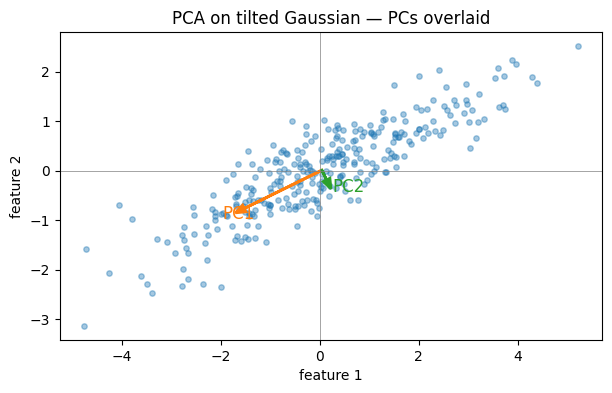

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mlscratch.decomposition import PCAEig

# Generate tilted 2D Gaussian
rng = np.random.default_rng(42)
X = rng.multivariate_normal(mean=[0, 0], cov=[[3, 1.5], [1.5, 1]], size=300)

# Fit
pca = PCAEig(n_components=2).fit(X)

# Plot
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(X[:, 0], X[:, 1], alpha=0.4, s=15)

for i in range(2):
    pc = pca.components_[i]
    length = np.sqrt(pca.explained_variance_[i])
    ax.arrow(
        pca.mean_[0], pca.mean_[1],
        pc[0] * length, pc[1] * length,
        head_width=0.15, head_length=0.2,
        fc=f"C{i+1}", ec=f"C{i+1}", linewidth=2,
        length_includes_head=True,
    )
    ax.text(
        pca.mean_[0] + pc[0] * length * 1.15,
        pca.mean_[1] + pc[1] * length * 1.15,
        f"PC{i+1}",
        fontsize=12, color=f"C{i+1}",
    )

ax.set_aspect("equal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")
ax.set_title("PCA on tilted Gaussian — PCs overlaid")
plt.show()